In [1]:
# from cluster_paths import get_cluster_paths
# scratch_path, repo_path = get_cluster_paths()
scratch_path = "/iopsstor/scratch/cscs/athomsen"
repo_path = "/users/athomsen/dlss/repos"

%load_ext autoreload
%autoreload 2

import os, h5py
import numpy as np
import matplotlib.pyplot as plt
from trianglechain import TriangleChain

from msfm.utils import files
from msi.utils import input_output

rng = np.random.default_rng(12)

/users/athomsen/dlss/torch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# v16

In [2]:
subversion = "rot_in_place"

msfm_conf = files.load_config(f"{repo_path}/multiprobe-simulation-forward-model/configs/v16/{subversion}.yaml")


## cls

In [3]:
base_dir = f"{scratch_path}/deep_lss/runs/v16/{subversion}/cls"


In [4]:
probe = "lensing"
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

# model_name = "v5"
# n_steps = 1_000_000

# model_name = "v5_diag"
# n_steps = 500_000

# model_name = "v5_weight_decay"
# n_steps = 500_000

# model_name = "v5_small"
# n_steps = 500_000

model_name = "v22"
n_steps = 1_000_000


In [5]:
# probe = "clustering"
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# model_name = "v5_small"
# n_steps = 500_000


In [6]:
# probe = "combined"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

# model_name = "v5_small"
# n_steps = 500_000


In [7]:
# probe = "2x2pt"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

# model_name = "v5_small"
# n_steps = 500_000


## common

# prior predictive checks

## scatterplot

In [8]:
pred_dir = os.path.join(base_dir, probe, model_name)
pred_file = os.path.join(pred_dir, f"preds_{n_steps}.h5")
print(f"pred_file = {pred_file}")

grid_preds, grid_cosmos, _, _ = input_output.load_network_preds_simple(pred_file)


pred_file = /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v22/preds_1000000.h5
26-06-10 09:07:51 input_output INF   Loading predictions from /iopsstor/scratch/cscs/athomsen/deep_lss/runs/v16/rot_in_place/cls/lensing/v22/preds_1000000.h5 
26-06-10 09:07:51 input_output INF   grid_preds.shape = (200000, 12) 
26-06-10 09:07:51 input_output INF   grid_cosmos.shape = (200000, 6) 
26-06-10 09:07:51 input_output INF   DESy3 with shape (12,) 
26-06-10 09:07:51 input_output INF   fiducial_bench_mean with shape (12,) 
26-06-10 09:07:51 input_output INF   fiducial_bench_stack with shape (80, 12) 
26-06-10 09:07:51 input_output INF   grid_(1,64,0) with shape (12,) 
26-06-10 09:07:51 input_output INF   grid_(2,64,0) with shape (12,) 
26-06-10 09:07:51 input_output INF   grid_(3,64,0) with shape (12,) 
26-06-10 09:07:51 input_output INF   grid_(4,64,0) with shape (12,) 


100%|██████████| 66/66 [00:00<00:00, 549.54it/s]


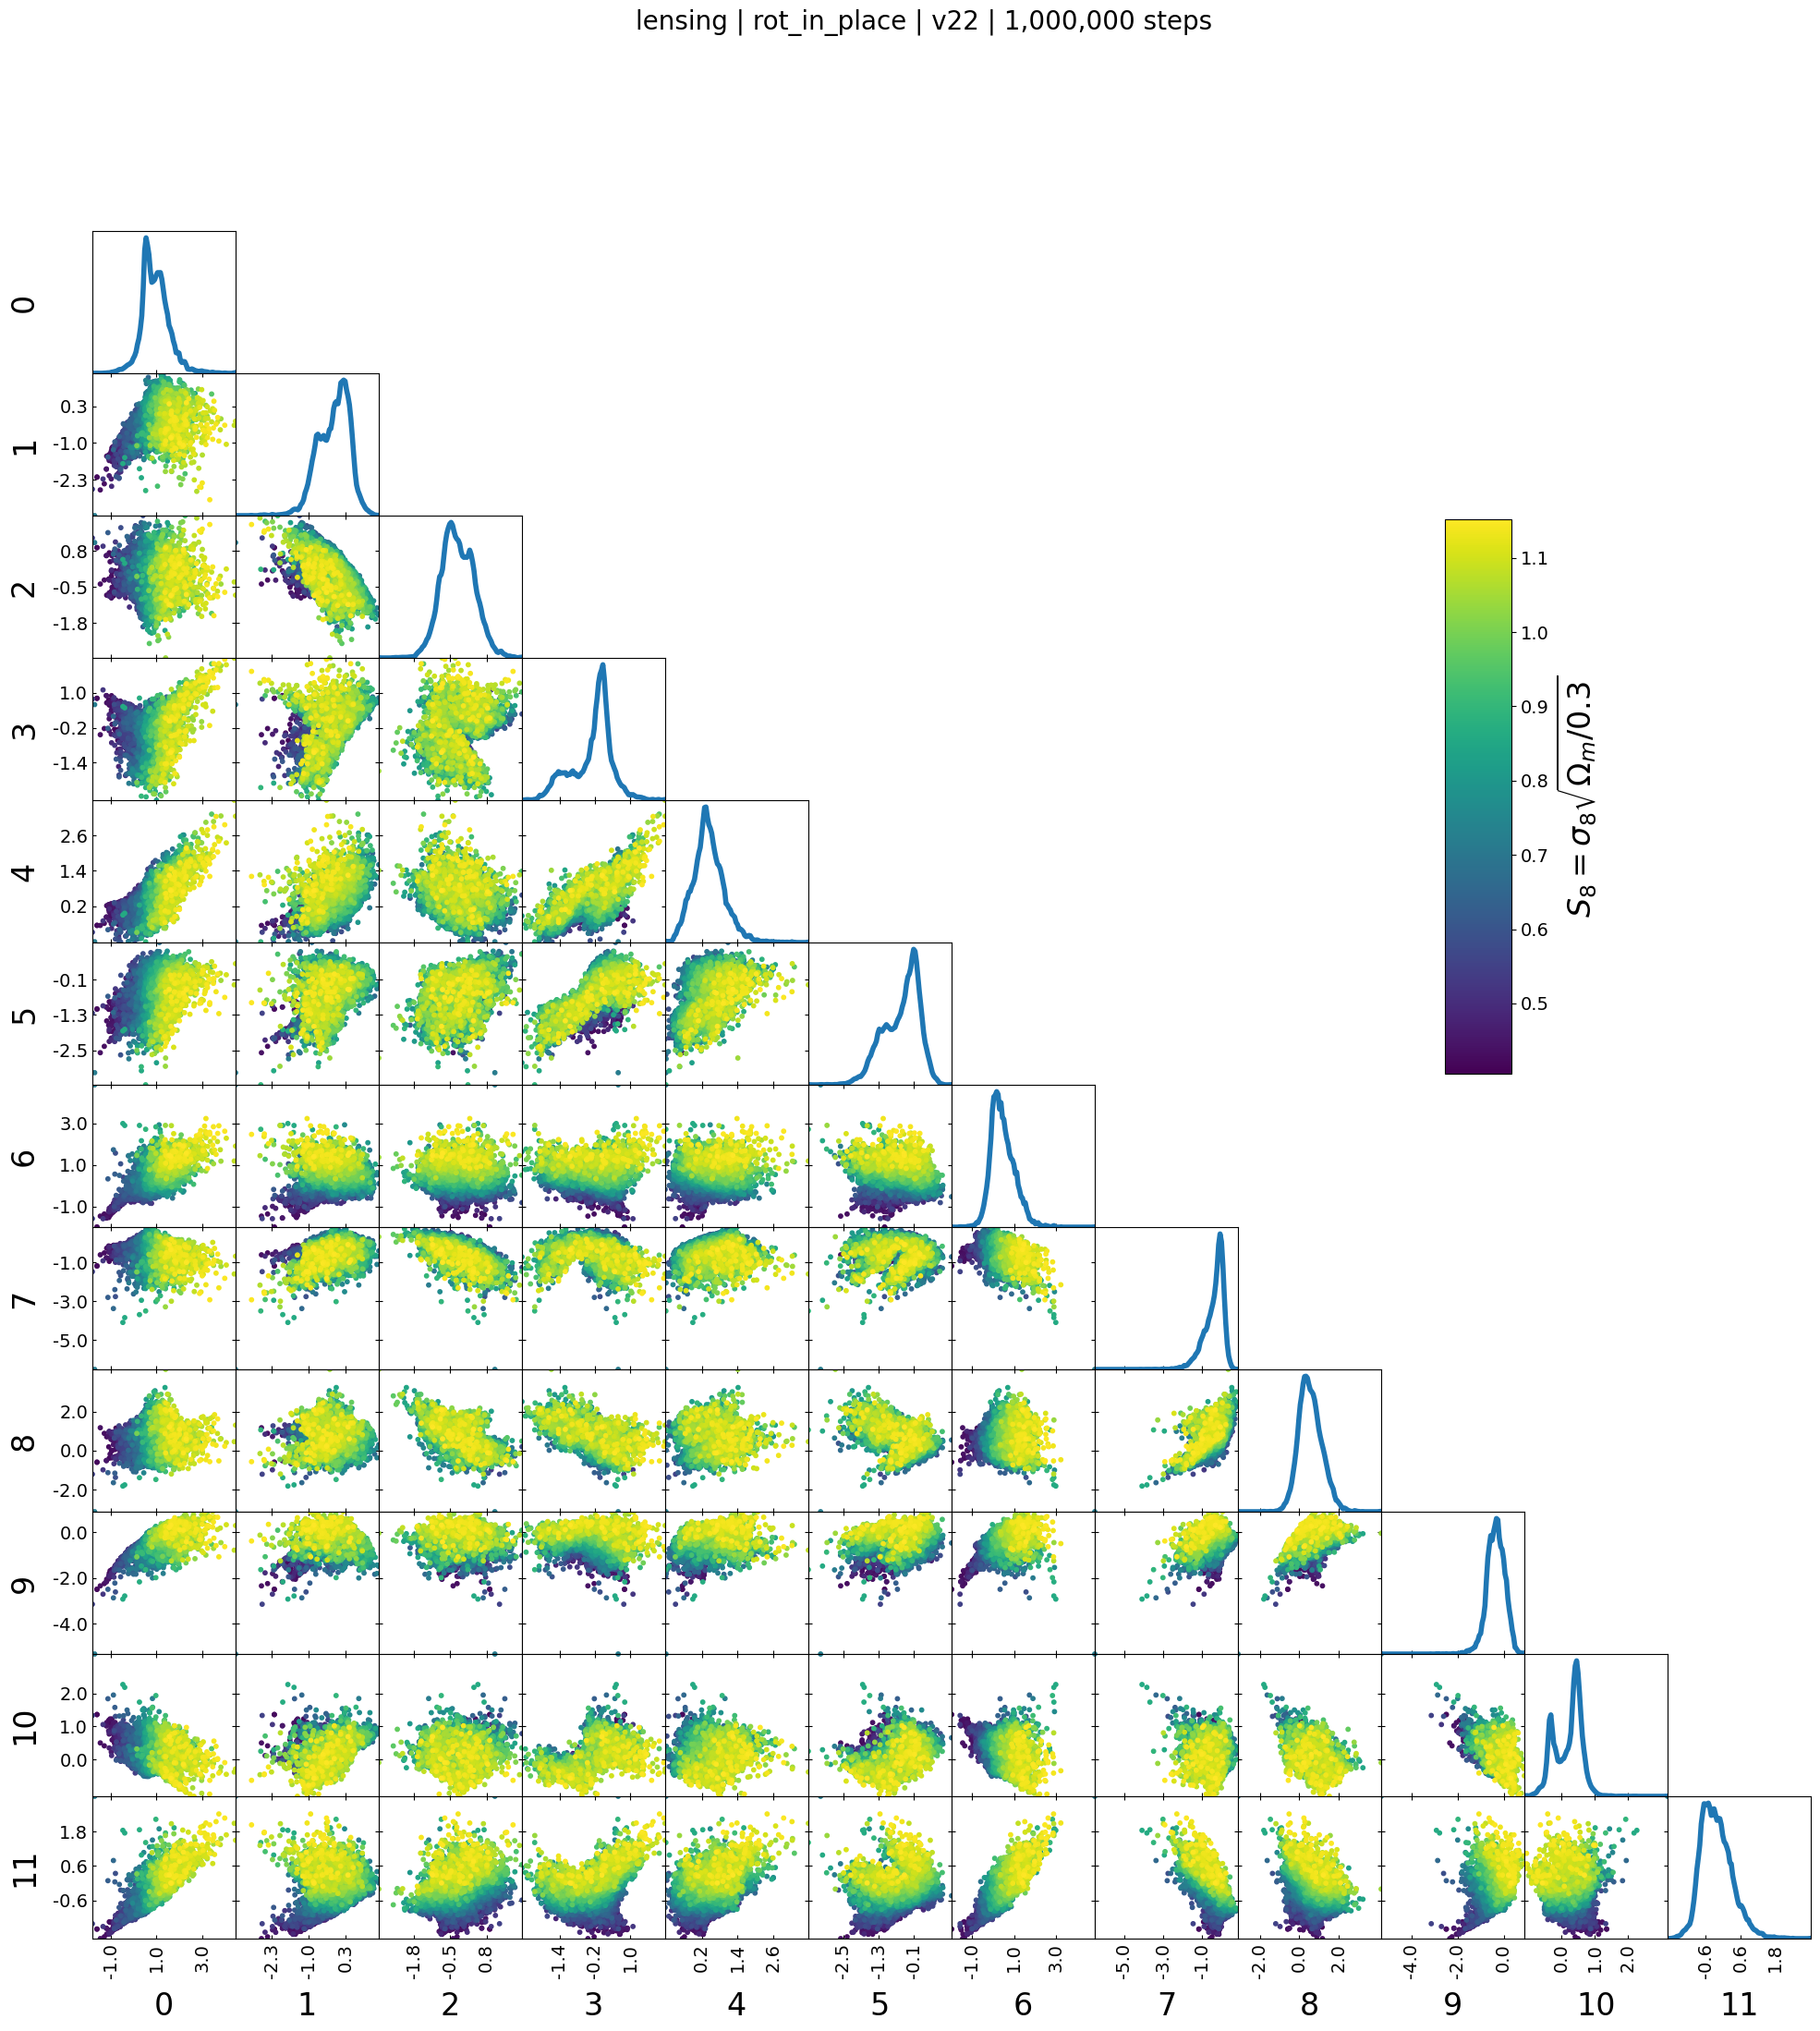

In [9]:
i_rand = rng.integers(0, grid_preds.shape[0], 10_000)

i_Om = params.index("Om")
i_s8 = params.index("s8")
S8 = grid_cosmos[i_rand, i_s8] * np.sqrt(grid_cosmos[i_rand, i_Om] / 0.3)

tri = TriangleChain(
    size=2,
    cmap="viridis",
    colorbar=True,
    colorbar_label=r"$S_8 = \sigma_8 \sqrt{\Omega_m / 0.3}$",
)
tri.scatter_prob(
    np.array(grid_preds)[i_rand],
    prob=S8,
    scatter_kwargs={"s": 10, "marker": "o"},
    normalize_prob2D=False,
);
tri.fig.suptitle(
    f"{probe} | {subversion} | {model_name} | {n_steps:,} steps",
    fontsize=20,
);